In [ ]:
import glob
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf

DATA_DIR = Path('../data')

In [3]:
# from osf import sync_osf
# csv_files = sync_osf(DATA_DIR / "raw")

In [4]:
csv_files = glob.glob(f'{DATA_DIR}/raw/*.csv')

In [13]:
sessions = [pd.read_csv(f) for f in csv_files]
kept_columns = ['random_id', 'chunk_length', 'chunk', 'rt', 'round_index', 'bot_move', 'player_move', 'policy_phase', 'outcome']
valid_sessions = []

for df_tidy, fname in zip(sessions, csv_files):
    scored_rounds = df_tidy.loc[(df_tidy['task_phase'] == 'rps') & (df_tidy['practice'] == False)]
    if scored_rounds.shape[0] < 100:
        print(f'Skipping {fname}')
        continue
    session = scored_rounds[kept_columns]
    
    valid_sessions.append(session)

df_tidy = pd.concat(valid_sessions, ignore_index=True)

# Cast to appropriate dtypes
column_dtypes = {
    'round_index': int,
    'policy_phase': int,
}

df_tidy = df_tidy.astype(column_dtypes)
df_tidy['won'] = df_tidy['outcome'].map({'win': True, 'loss': False})
df_tidy = df_tidy.drop('outcome', axis=1)

display(df_tidy.head())
display(df_tidy.describe())

,random_id,chunk_length,chunk,rt,round_index,bot_move,player_move,policy_phase,won
0,dl0qsocc4e,4,prsr,1468.0,1,p,s,0,True
1,dl0qsocc4e,4,prsr,712.0,2,r,s,1,False
2,dl0qsocc4e,4,prsr,1034.0,3,s,s,2,False
3,dl0qsocc4e,4,prsr,769.0,4,r,p,3,True
4,dl0qsocc4e,4,prsr,723.0,5,p,p,0,False


,chunk_length,rt,round_index,policy_phase
count,3700.000000,3587.000000,3700.000000,3700.000000
mean,3.513514,764.559799,50.500000,0.802973
std,1.105948,694.888680,28.869972,1.129056
min,2.000000,1.000000,1.000000,0.000000
25%,3.000000,280.000000,25.750000,0.000000
50%,4.000000,464.000000,50.500000,0.000000
75%,4.000000,1047.000000,75.250000,1.000000
max,5.000000,2991.000000,100.000000,4.000000


In [14]:
# Remove any participants with unrealistic data
MAX_POLICY_ACC = 0.95

df = df_tidy.copy()

mean_rt = df.groupby('random_id')['rt'].mean()
extreme_rt_ids = mean_rt[(mean_rt < 150)].index
df = df[~df['random_id'].isin(extreme_rt_ids)]
print(f"Removed {len(extreme_rt_ids)} participants with mean rt < 150")

move_counts = df.groupby('random_id')['player_move'].nunique()
low_move_var_ids = move_counts[move_counts < 3].index
df = df[~df['random_id'].isin(low_move_var_ids)]
print(f"Removed {len(low_move_var_ids)} participants using fewer than 3 moves")

mean_acc = df.loc[df['policy_phase'] > 0].groupby('random_id')['won'].mean()

high_acc_ids = mean_acc[mean_acc > MAX_POLICY_ACC].index
df = df[~df['random_id'].isin(high_acc_ids)]
print(f"Removed {len(high_acc_ids)} participants with greater than {MAX_POLICY_ACC} mean accuracy")

Removed 0 participants with mean rt < 150
Removed 0 participants using fewer than 3 moves
Removed 1 participants with greater than 0.95 mean accuracy


In [15]:
df.to_csv(f'{DATA_DIR}/clean.csv', index=False)

In [16]:
# Filter the dataframe by rounds during which the participant
# passed a threshold minimum mean accuracy
# (i.e. had "learned" the hidden policy)

BURN_ROUNDS = 50
ACC_THRESHOLD = 0.7

df_latter = df.loc[df['round_index'] > BURN_ROUNDS].copy()
latter_acc = df_latter.loc[df['policy_phase'] > 0].groupby('random_id')['won'].mean()
latter_acc_hi = latter_acc[latter_acc > ACC_THRESHOLD]
hiacc_ids = latter_acc_hi.index
df_hiacc = df.loc[df['random_id'].isin(hiacc_ids)].copy()

print(df_hiacc['random_id'].nunique())

df_hiacc.to_csv(DATA_DIR / 'hiacc.csv', index=False)

7


/Users/dan/venv/cogs180/.venv/lib/python3.14/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/dan/venv/cogs180/.venv/lib/python3.14/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/dan/venv/cogs180/.venv/lib/python3.14/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/dan/venv/cogs180/.venv/lib/python3.14/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/dan/venv/cogs180/.venv/lib/python3.14/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/dan/venv/cogs180/.venv/lib/python3.14/site-packages/seaborn/reg

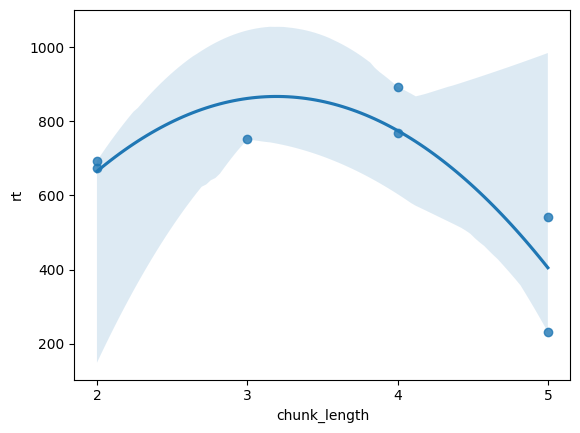

In [17]:
chunk_lengths_hi = df_hiacc.groupby('random_id')['chunk_length'].first()
rt_hi = df_hiacc.groupby('random_id')['rt'].mean()

ax = sns.regplot(x=chunk_lengths_hi, y=rt_hi, order=2)
ax.set_xticks(range(2, 6))

In [18]:
cl_vs_rt = smf.ols('rt ~ chunk_length + I(chunk_length**2)', data={
    'rt': rt_hi,
    'chunk_length': chunk_lengths_hi,
}).fit()

cl_vs_rt.summary()

/Users/dan/venv/cogs180/.venv/lib/python3.14/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     rt   R-squared:                       0.721
Model:                            OLS   Adj. R-squared:                  0.582
Method:                 Least Squares   F-statistic:                     5.177
Date:                Tue, 10 Mar 2026   Prob (F-statistic):             0.0777
Time:                        08:39:31   Log-Likelihood:                -42.459
No. Observations:                   7   AIC:                             90.92
Df Residuals:                       4   BIC:                             90.76
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept             -579.3018    586.125     -0.988      0.379   -2206.647    1048.043
chunk_length           905.7654    369.059      2.454      0.070    -118.906    1930.437
I(chunk_length ** 2)  -141.7830     52.786     -2.686      0.055    -288.341       4.775
==============================================================================
Omnibus:                          nan   Durbin-Watson:                   1.579
Prob(Omnibus):                    nan   Jarque-Bera (JB):                0.428
Skew:                          -0.296   Prob(JB):                        0.807
Kurtosis:                       1.943   Cond. No.                         223.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<Axes: xlabel='chunk_length', ylabel='won'>

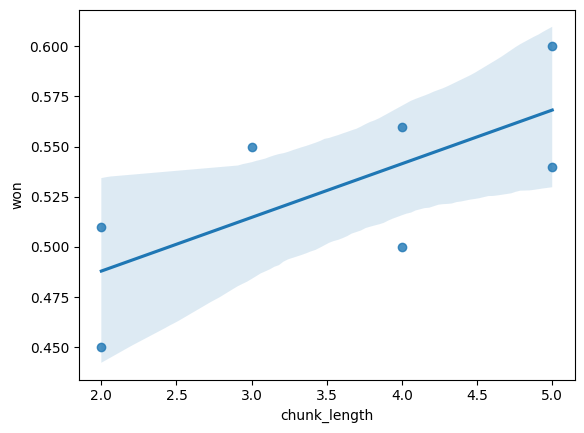

In [19]:
acc_hi = df_hiacc.groupby('random_id')['won'].mean()
sns.regplot(x=chunk_lengths_hi, y=acc_hi)

In [20]:
cl_vs_acc = smf.ols('acc_hi ~ chunk_length', data={
    'acc_hi': acc_hi,
    'chunk_length': chunk_lengths_hi,
}).fit()

cl_vs_acc.summary()

/Users/dan/venv/cogs180/.venv/lib/python3.14/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 acc_hi   R-squared:                       0.497
Model:                            OLS   Adj. R-squared:                  0.396
Method:                 Least Squares   F-statistic:                     4.942
Date:                Tue, 10 Mar 2026   Prob (F-statistic):             0.0768
Time:                        08:39:35   Log-Likelihood:                 14.224
No. Observations:                   7   AIC:                            -24.45
Df Residuals:                       5   BIC:                            -24.56
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.4344      0.045      9.594      0.000       0.318       0.551
chunk_length     0.0268      0.012      2.223      0.077      -0.004       0.058
==============================================================================
Omnibus:                          nan   Durbin-Watson:                   2.447
Prob(Omnibus):                    nan   Jarque-Bera (JB):                1.003
Skew:                          -0.248   Prob(JB):                        0.606
Kurtosis:                       1.213   Cond. No.                         12.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

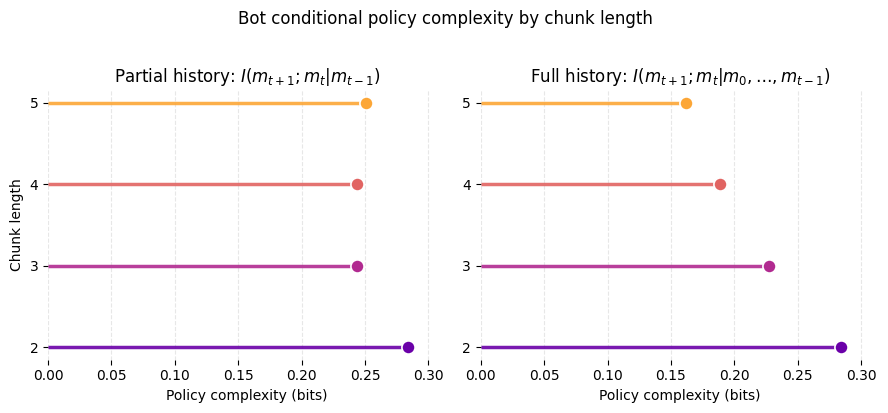

In [ ]:
# Policy complexity (as a function of chunk length) conditioned on
#   - partial history (len(h) = 1)
#   - full history (len(h) = inf)

chunk_lengths = np.array(range(2, 6))
cpc_h1 = np.array([0.284, 0.244, 0.244, 0.251])
cpc_hinf = np.array([0.284, 0.227, 0.189, 0.162])

palette = sns.color_palette("plasma", n_colors=len(chunk_lengths))
colors = dict(zip(chunk_lengths, palette))
xmax = max(cpc_h1.max(), cpc_hinf.max()) + 0.03

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True)
series = [
    (axes[0], cpc_h1, r"Partial history: $I(m_{t+1};m_t|m_{t-1})$"),
    (axes[1], cpc_hinf, r"Full history: $I(m_{t+1};m_t|m_0, \ldots, m_{t-1})$"),
]

for ax, values, title in series:
    for y, x in zip(chunk_lengths, values):
        ax.hlines(y=y, xmin=0, xmax=x, color=colors[y], linewidth=2.5, alpha=0.9)
        ax.scatter(x, y, s=90, color=colors[y], edgecolor="white", linewidth=1.2, zorder=3)

    ax.set_title(title)
    ax.set_xlim(0, xmax)
    ax.set_xlabel("Policy complexity (bits)")
    ax.grid(axis="x", linestyle="--", alpha=0.3)

axes[0].set_ylabel("Chunk length")
axes[0].set_yticks(chunk_lengths)
axes[0].set_yticklabels(chunk_lengths)
axes[1].tick_params(axis="y", labelleft=True)
axes[1].set_yticks(chunk_lengths)
axes[1].set_yticklabels(chunk_lengths)

sns.despine(left=True, bottom=True)
fig.suptitle("Bot conditional policy complexity by chunk length", y=1.02)
fig.tight_layout()
plt.show()
